In [53]:
%pip uninstall readability -y

Note: you may need to restart the kernel to use updated packages.


In [79]:
import os
import time
import re
import pandas as pd
import numpy as np
import mediacloud.api
import trafilatura
import plotly.express as px

from urllib.parse import urlsplit, urlunsplit, parse_qsl, urlencode
from tqdm.auto import tqdm
from datetime import date
from tenacity import retry, stop_after_attempt, wait_exponential
# from readability import Document
from readability.readability import Document
from bs4 import BeautifulSoup
from newspaper import fulltext

* active fire: Jan 7–31, 2025
* early recovery: Feb 1–Mar 31, 2025
* longer-tail aftermath: Apr 1–Jun 30, 2025

In [55]:
MEDIA_CLOUD_API_KEY = "b378b3608cf1ec5d471144681e9ec05560c64fee"
# START_DATE = "2025-01-07"
# END_DATE = "2025-01-14"
START_DATE = date(2025, 1, 7)
END_DATE = date(2025, 6, 30)
# QUERY = '"Eaton Fire" OR ((Altadena OR Pasadena) AND (fire OR wildfire))'
QUERY = '"Eaton Fire" OR (Altadena AND fire) OR (Pasadena AND fire AND wildfire)'
COLLECTION_IDS = None
MAX_STORIES = None
MIN_TEXT_CHARS = 1000
SLEEP_BETWEEN_REQUESTS = 1  # polite delay for article fetching

In [56]:
def clean_url(url):
    """
    Normalize URL a bit for deduping
    """
    if not isinstance(url, str) or not url.strip():
        return None

    bad_params = {
        "utm_source", "utm_medium", "utm_campaign", "utm_term", "utm_content",
        "fbclid", "gclid", "mc_cid", "mc_eid", "ocid", "cmpid", "guccounter"
    }

    parts = urlsplit(url)
    kept_query = []

    for key, value in parse_qsl(parts.query, keep_blank_values=True):
        if key.lower() not in bad_params:
            kept_query.append((key, value))

    new_query = urlencode(kept_query, doseq=True)

    cleaned = urlunsplit((
        parts.scheme.lower(),
        parts.netloc.lower(),
        parts.path,
        new_query,
        ""  # remove fragment
    ))

    return cleaned

In [57]:
def normalize_text_for_hashing(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [58]:
@retry(wait=wait_exponential(multiplier=1, min=2, max=10), stop=stop_after_attempt(3))
def extract_article_text(html):
    text = trafilatura.extract(
        html,
        include_comments=False,
        include_tables=False,
        fast=True,
        favor_precision=False,
        output_format="txt"
    )
    if text and text.strip():
        return text

    try:
        doc = Document(html)
        content_html = doc.summary()
        text = BeautifulSoup(content_html, "html.parser").get_text("\n", strip=True)
        if text:
            return text
    except Exception:
        pass

    try:
        text = fulltext(html)
        if text:
            return text
    except Exception:
        pass

    return None
# def download_article_text(url):
#     """
#     Fetch and extract article text from a URL using trafilatura.
#     """
#     downloaded = trafilatura.fetch_url(url)
#     if downloaded is None:
#         return None

#     extracted = trafilatura.extract(
#         downloaded,
#         include_comments=False,
#         include_tables=False,
#         favor_precision=True,
#         output_format="txt"
#     )
#     return extracted

In [31]:
backup_csv = "data/raw_mediacloud_stories_backup.csv"
token_txt = "data/mediacloud_pagination_token.txt"
mc = mediacloud.api.SearchApi(MEDIA_CLOUD_API_KEY)

if os.path.exists(backup_csv):
    all_rows = pd.read_csv(backup_csv).to_dict("records")
else:
    all_rows = []

if os.path.exists(token_txt):
    with open(token_txt, "r") as f:
        pagination_token = f.read().strip()
        if pagination_token == "":
            pagination_token = None
else:
    pagination_token = None

use_cap = MAX_STORIES is not None
pbar = tqdm(initial=len(all_rows), total=MAX_STORIES if use_cap else None, desc="Pulling story metadata")

consecutive_failures = 0

while True:
    if use_cap and len(all_rows) >= MAX_STORIES:
        break

    kwargs = {
        "query": QUERY,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "pagination_token": pagination_token,
    }
    if COLLECTION_IDS is not None:
        kwargs["collection_ids"] = COLLECTION_IDS

    try:
        page, next_token = mc.story_list(**kwargs)
        consecutive_failures = 0
    except Exception as e:
        consecutive_failures += 1
        print(f"story_list failed ({consecutive_failures}): {type(e).__name__}: {e}")

        # save progress before retrying
        pd.DataFrame(all_rows).to_csv(backup_csv, index=False)
        with open(token_txt, "w") as f:
            f.write("" if pagination_token is None else str(pagination_token))

        if consecutive_failures >= 5:
            print("Too many failures in a row. Stopping so you can resume later.")
            break

        time.sleep(60)  # back off
        continue

    if not page:
        print("No more pages returned.")
        break

    for story in page:
        row = {
            "mc_id": story.get("id"),
            "title": story.get("title"),
            "media_name": story.get("media_name"),
            "media_url": story.get("media_url"),
            "publish_date": story.get("publish_date"),
            "indexed_date": story.get("indexed_date"),
            "language": story.get("language"),
            "url": story.get("url"),
        }
        all_rows.append(row)
        pbar.update(1)

        if use_cap and len(all_rows) >= MAX_STORIES:
            break

    pagination_token = next_token

    # save every page
    pd.DataFrame(all_rows).to_csv(backup_csv, index=False)
    with open(token_txt, "w") as f:
        f.write("" if pagination_token is None else str(pagination_token))

    if pagination_token is None:
        print("Reached final page.")
        break

    time.sleep(35)  # gentle pacing

pbar.close()

stories_df = pd.DataFrame(all_rows)
stories_df.to_csv("data/all_stories.csv", index=False)

print("Raw rows:", len(stories_df))
stories_df.head()

Pulling story metadata: 2000it [00:00, ?it/s]

Reached final page.
Raw rows: 46908


,mc_id,title,media_name,media_url,publish_date,indexed_date,language,url
0,a6e093e0815ba190786c0b670db443ce5f2c24391c2350...,Southern California Edison lays out 925 millio...,newindiaabroad.com,newindiaabroad.com,2025-04-12,2026-04-06 23:43:12.149172+00:00,en,https://www.newindiaabroad.com/english/news/so...
1,f71528bebff93ea8408cbca580c425521e0dfc4b9cab3d...,Caltech launches limitedseries podcast on LA w...,newindiaabroad.com,newindiaabroad.com,2025-03-29,2026-04-06 23:16:22.909784+00:00,en,https://www.newindiaabroad.com/english/news/ca...
2,2adb895555636f8a5393b7b39f4ca738de573f80d3f882...,Indian American organizations raising funds to...,newindiaabroad.com,newindiaabroad.com,2025-03-22,2026-04-06 21:03:36.281907+00:00,en,https://www.newindiaabroad.com/english/indian%...
3,bdd33b2ee19920eddb2b1c184e3ab428b0566aa50d22a1...,Calmer winds help Los Angeles firefighters as ...,newindiaabroad.com,newindiaabroad.com,2025-01-10,2026-04-06 14:15:10.520105+00:00,en,https://www.newindiaabroad.com/english/news/ca...
4,081795dabe2317513235bcab47943615d88980b8e62946...,Californiaseeks 1 billion from insurers to sho...,newindiaabroad.com,newindiaabroad.com,2025-02-12,2026-04-06 14:12:26.839437+00:00,en,https://www.newindiaabroad.com/english/news/ca...


In [32]:
stories_df['title'].head()

0    Southern California Edison lays out 925 millio...
1    Caltech launches limitedseries podcast on LA w...
2    Indian American organizations raising funds to...
3    Calmer winds help Los Angeles firefighters as ...
4    Californiaseeks 1 billion from insurers to sho...
Name: title, dtype: object

In [33]:
stories_df["clean_url"] = stories_df["url"].apply(clean_url)
stories_df = stories_df[stories_df["language"].fillna("").eq("en")].copy()
stories_df = stories_df[stories_df["clean_url"].notna()].copy()
# dedupe by Media Cloud ID if present
stories_df = stories_df.drop_duplicates(subset=["mc_id"])
stories_df = stories_df.drop_duplicates(subset=["clean_url"])
stories_df["title"] = stories_df["title"].fillna("").str.strip()

print("After metadata dedupe:", len(stories_df))
stories_df.head()

After metadata dedupe: 40901


,mc_id,title,media_name,media_url,publish_date,indexed_date,language,url,clean_url
0,a6e093e0815ba190786c0b670db443ce5f2c24391c2350...,Southern California Edison lays out 925 millio...,newindiaabroad.com,newindiaabroad.com,2025-04-12,2026-04-06 23:43:12.149172+00:00,en,https://www.newindiaabroad.com/english/news/so...,https://www.newindiaabroad.com/english/news/so...
1,f71528bebff93ea8408cbca580c425521e0dfc4b9cab3d...,Caltech launches limitedseries podcast on LA w...,newindiaabroad.com,newindiaabroad.com,2025-03-29,2026-04-06 23:16:22.909784+00:00,en,https://www.newindiaabroad.com/english/news/ca...,https://www.newindiaabroad.com/english/news/ca...
2,2adb895555636f8a5393b7b39f4ca738de573f80d3f882...,Indian American organizations raising funds to...,newindiaabroad.com,newindiaabroad.com,2025-03-22,2026-04-06 21:03:36.281907+00:00,en,https://www.newindiaabroad.com/english/indian%...,https://www.newindiaabroad.com/english/indian%...
3,bdd33b2ee19920eddb2b1c184e3ab428b0566aa50d22a1...,Calmer winds help Los Angeles firefighters as ...,newindiaabroad.com,newindiaabroad.com,2025-01-10,2026-04-06 14:15:10.520105+00:00,en,https://www.newindiaabroad.com/english/news/ca...,https://www.newindiaabroad.com/english/news/ca...
4,081795dabe2317513235bcab47943615d88980b8e62946...,Californiaseeks 1 billion from insurers to sho...,newindiaabroad.com,newindiaabroad.com,2025-02-12,2026-04-06 14:12:26.839437+00:00,en,https://www.newindiaabroad.com/english/news/ca...,https://www.newindiaabroad.com/english/news/ca...


### Fetch text

In [61]:
if "text" not in stories_df.columns:
    stories_df["text"] = None
if "text_len" not in stories_df.columns:
    stories_df["text_len"] = 0

In [62]:
texts = []
for i, url in enumerate(tqdm(stories_df["clean_url"], desc="Downloading article text")):
    try:
        text = download_article_text(url)
    except Exception:
        text = None
    texts.append(text)
    if text is not None and str(text).strip() != "":
        stories_df.at[i, "text"] = text
        stories_df.at[i, "text_len"] = len(text)
        stories_df.to_csv("data/all_stories_with_text.csv")
    else:
        stories_df.at[i, "text"] = None
        stories_df.at[i, "text_len"] = 0
    time.sleep(SLEEP_BETWEEN_REQUESTS)

# stories_df["text"] = texts
# stories_df["text_len"] = stories_df["text"].fillna("").str.len()
stories_df.to_csv("data/all_stories_with_text.csv", index=False)
print(stories_df["text_len"].describe())

count     45959.000000
mean       3827.548141
std        5576.871228
min           0.000000
25%           0.000000
50%        2730.000000
75%        5728.000000
max      116306.000000
Name: text_len, dtype: float64


In [71]:
# Real story rows, in the correct original order
meta_df = stories_df[stories_df["mc_id"].notna()].copy().reset_index(drop=True)

n = len(meta_df)
print("real story rows:", n)

# These row labels 0..n-1 now contain the text for positions 0..n-1
text_source = stories_df.reindex(range(n)).copy()

# Build the fixed dataframe
fixed_df = meta_df.copy()

fixed_df["text"] = text_source["text"].values
fixed_df["text_len"] = pd.to_numeric(
    text_source["text_len"], errors="coerce"
).fillna(0).astype(int).values

print("fixed rows:", len(fixed_df))
print("rows with text:", fixed_df["text"].notna().sum())

fixed_df.to_csv("data/all_stories_fixed.csv", index=False)

real story rows: 40901
fixed rows: 40901
rows with text: 33287


In [72]:
fixed_df

,mc_id,title,media_name,media_url,publish_date,indexed_date,language,url,clean_url,text,text_len
0,a6e093e0815ba190786c0b670db443ce5f2c24391c2350...,Southern California Edison lays out 925 millio...,newindiaabroad.com,newindiaabroad.com,2025-04-12,2026-04-06 23:43:12.149172+00:00,en,https://www.newindiaabroad.com/english/news/so...,https://www.newindiaabroad.com/english/news/so...,"Southern California Edison (SCE), a subsidiary...",1333
1,f71528bebff93ea8408cbca580c425521e0dfc4b9cab3d...,Caltech launches limitedseries podcast on LA w...,newindiaabroad.com,newindiaabroad.com,2025-03-29,2026-04-06 23:16:22.909784+00:00,en,https://www.newindiaabroad.com/english/news/ca...,https://www.newindiaabroad.com/english/news/ca...,The Los Angeles wildfires of January 2025 resu...,1370
2,2adb895555636f8a5393b7b39f4ca738de573f80d3f882...,Indian American organizations raising funds to...,newindiaabroad.com,newindiaabroad.com,2025-03-22,2026-04-06 21:03:36.281907+00:00,en,https://www.newindiaabroad.com/english/indian%...,https://www.newindiaabroad.com/english/indian%...,It’s been over two months since the start of t...,3779
3,bdd33b2ee19920eddb2b1c184e3ab428b0566aa50d22a1...,Calmer winds help Los Angeles firefighters as ...,newindiaabroad.com,newindiaabroad.com,2025-01-10,2026-04-06 14:15:10.520105+00:00,en,https://www.newindiaabroad.com/english/news/ca...,https://www.newindiaabroad.com/english/news/ca...,A pause in the fierce winds that super-charged...,6126
4,081795dabe2317513235bcab47943615d88980b8e62946...,Californiaseeks 1 billion from insurers to sho...,newindiaabroad.com,newindiaabroad.com,2025-02-12,2026-04-06 14:12:26.839437+00:00,en,https://www.newindiaabroad.com/english/news/ca...,https://www.newindiaabroad.com/english/news/ca...,California Insurance Commissioner Ricardo Lara...,1761
...,...,...,...,...,...,...,...,...,...,...,...
40896,15c7f42cb89d0b7b2d9557f40b08f9a12638f8912f4817...,'Life-threatening' winds set to hit Southern C...,latimes.com,latimes.com,2025-01-07,2025-01-07 16:25:10.398853+00:00,en,https://www.latimes.com/california/story/2025-...,https://www.latimes.com/california/story/2025-...,"Pacific Palisades fire explodes to nearly 3,00...",10111
40897,17a137cb22a1cf6b48f1c960c9eaca25551494d3f05994...,Windstorm in California: NWS sends warning for...,usatoday.com,usatoday.com,2025-01-07,2025-01-07 16:23:13.621899+00:00,en,https://www.usatoday.com/story/news/weather/20...,https://www.usatoday.com/story/news/weather/20...,"'Life-threatening, destructive windstorm' expe...",3985
40898,4194a3d33ab7ba2adcf334310e012b7dfefbadc36cf279...,Windstorm maps show Southern California areas ...,newsweek.com,newsweek.com,2025-01-07,2025-01-07 15:28:44.365859+00:00,en,https://www.newsweek.com/windstorm-map-souther...,https://www.newsweek.com/windstorm-map-souther...,Forecast maps have illustrated the areas on So...,3858
40899,b3d82b9c2e952a2137bbff78c58323679beef072313ec2...,'Life-threatening' windstorm expected to hit S...,6abc.com,6abc.com,2025-01-07,2025-01-07 14:31:59.748032+00:00,en,https://6abc.com/post/windstorm-expected-hit-l...,https://6abc.com/post/windstorm-expected-hit-l...,Brush fires erupt as powerful windstorm batter...,7663


In [73]:
pd.DataFrame({
    "title": fixed_df["title"].head(15),
    "text_preview": fixed_df["text"].head(15).str[:140],
    "text_len": fixed_df["text_len"].head(15)
})

,title,text_preview,text_len
0,Southern California Edison lays out 925 millio...,"Southern California Edison (SCE), a subsidiary...",1333
1,Caltech launches limitedseries podcast on LA w...,The Los Angeles wildfires of January 2025 resu...,1370
2,Indian American organizations raising funds to...,It’s been over two months since the start of t...,3779
3,Calmer winds help Los Angeles firefighters as ...,A pause in the fierce winds that super-charged...,6126
4,Californiaseeks 1 billion from insurers to sho...,California Insurance Commissioner Ricardo Lara...,1761
5,Indian American groups offer wildfire relief i...,As multiple wildfires continue to rage across ...,2388
6,LA firefighters hold the line despite extreme ...,"Firefighters on Jan. 14, held the line against...",5412
7,LA evacuees told stay away another week,Los Angeles officials told most evacuees from ...,5680
8,KUOW's Angela King goes to post-wildfire Altad...,Southern Californians are still working to rec...,763
9,Death toll from Los Angeles fires rises,The death toll from massive wildfires that hav...,5046


In [75]:
print("rows:", len(fixed_df))
print("rows with text:", fixed_df["text"].notna().sum())
print("rows with text_len > 0:", (fixed_df["text_len"] > 0).sum())
print("duplicate mc_id:", fixed_df["mc_id"].duplicated().sum())

rows: 40901
rows with text: 33287
rows with text_len > 0: 33287
duplicate mc_id: 0


In [76]:
fixed_df["text_len"].describe()

count     40901.000000
mean       4300.879807
std        5736.893200
min           0.000000
25%         968.000000
50%        3328.000000
75%        6034.000000
max      116306.000000
Name: text_len, dtype: float64

In [78]:
news_df = fixed_df[fixed_df["text_len"] >= 1000].copy()
news_df = news_df[news_df["language"] == "en"].copy()
print(len(news_df))

30598


In [80]:
report_df = fixed_df.copy()

# Parse dates
report_df["publish_date"] = pd.to_datetime(report_df["publish_date"], errors="coerce")
report_df["indexed_date"] = pd.to_datetime(report_df["indexed_date"], errors="coerce")

# Numeric text length
report_df["text_len"] = pd.to_numeric(report_df["text_len"], errors="coerce").fillna(0)

# Fill text
report_df["text"] = report_df["text"].fillna("")

# Flags
report_df["has_text"] = report_df["text_len"] > 0
report_df["usable_text"] = report_df["text_len"] >= 1000

print("Rows:", len(report_df))
print("Rows with text:", int(report_df["has_text"].sum()))
print("Rows with usable text:", int(report_df["usable_text"].sum()))

Rows: 40901
Rows with text: 33287
Rows with usable text: 30598


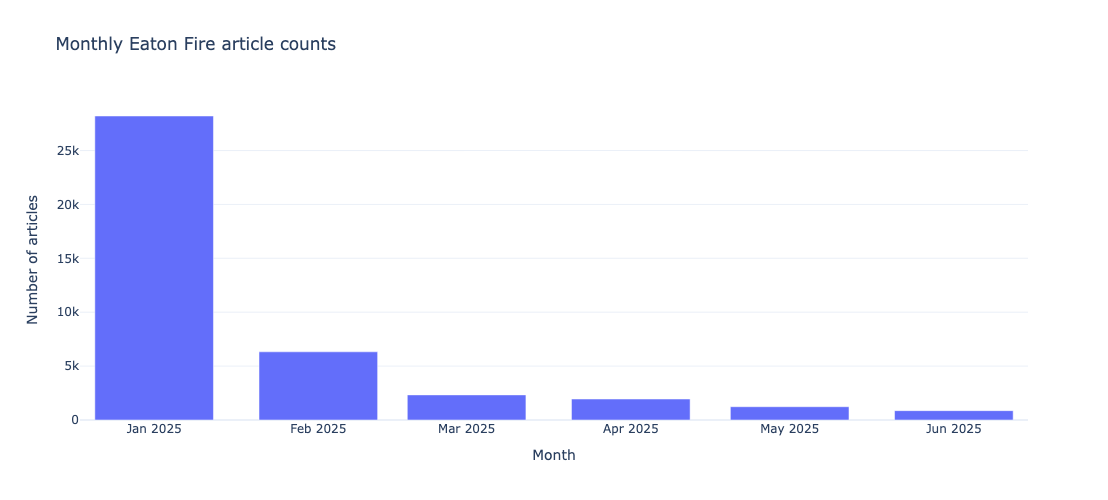

python3.10(56646) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [81]:
monthly_counts = (
    report_df.dropna(subset=["publish_date"])
    .assign(month=report_df["publish_date"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .reset_index(name="n_articles")
)

fig_monthly = px.bar(
    monthly_counts,
    x="month",
    y="n_articles",
    title="Monthly Eaton Fire article counts",
    labels={"month": "Month", "n_articles": "Number of articles"}
)

fig_monthly.update_layout(
    template="plotly_white",
    width=1000,
    height=500
)

fig_monthly.show()
fig_monthly.write_image("figures/monthly_article_counts.pdf")

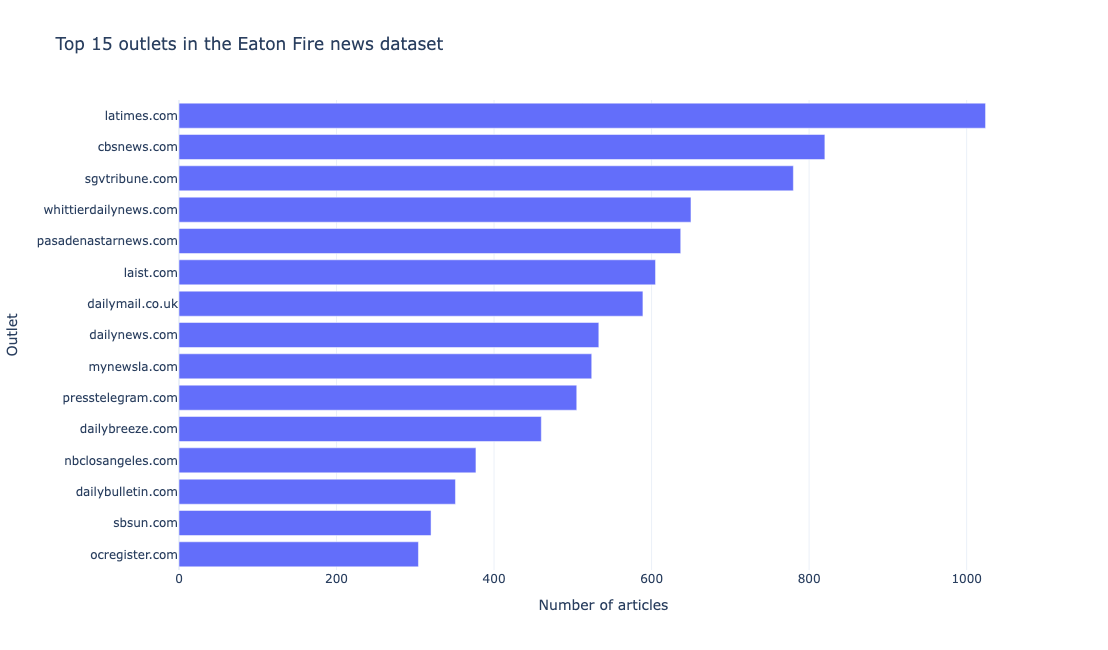

python3.10(56672) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [82]:
top_outlets = (
    report_df["media_name"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
    .reset_index()
)

top_outlets.columns = ["media_name", "n_articles"]

# Reverse for nicer horizontal ordering
top_outlets = top_outlets.sort_values("n_articles", ascending=True)

fig_outlets = px.bar(
    top_outlets,
    x="n_articles",
    y="media_name",
    orientation="h",
    title="Top 15 outlets in the Eaton Fire news dataset",
    labels={"media_name": "Outlet", "n_articles": "Number of articles"}
)

fig_outlets.update_layout(
    template="plotly_white",
    width=1000,
    height=650
)

fig_outlets.show()
fig_outlets.write_image("figures/top_15_outlets.pdf")

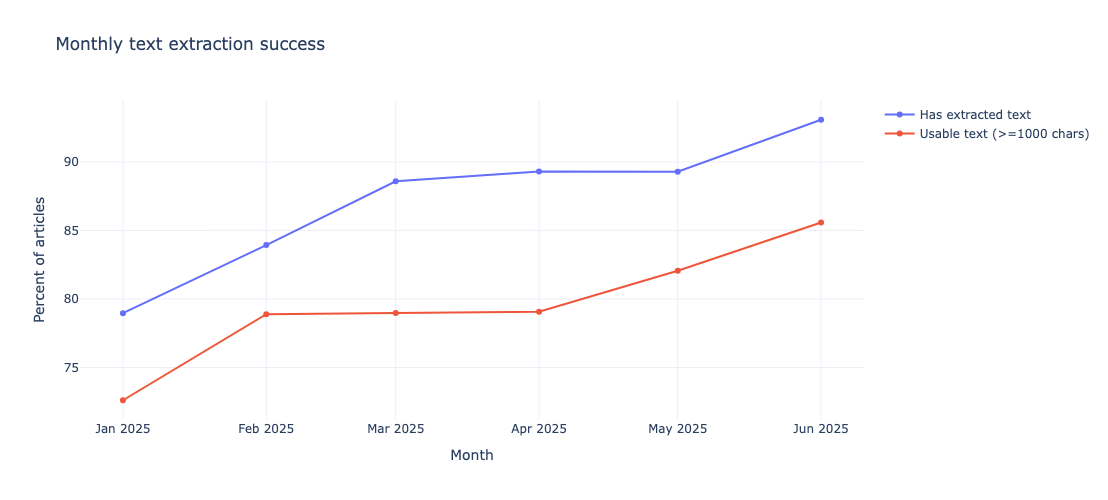

python3.10(56694) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [83]:
monthly_quality = (
    report_df.dropna(subset=["publish_date"])
    .assign(month=report_df["publish_date"].dt.to_period("M").astype(str))
    .groupby("month")
    .agg(
        total_articles=("mc_id", "count"),
        with_text=("has_text", "sum"),
        usable_text=("usable_text", "sum"),
        median_text_len=("text_len", "median")
    )
    .reset_index()
)

monthly_quality["pct_with_text"] = 100 * monthly_quality["with_text"] / monthly_quality["total_articles"]
monthly_quality["pct_usable_text"] = 100 * monthly_quality["usable_text"] / monthly_quality["total_articles"]

monthly_quality_long = monthly_quality.melt(
    id_vars="month",
    value_vars=["pct_with_text", "pct_usable_text"],
    var_name="metric",
    value_name="percent"
)

monthly_quality_long["metric"] = monthly_quality_long["metric"].replace({
    "pct_with_text": "Has extracted text",
    "pct_usable_text": "Usable text (>=1000 chars)"
})

fig_quality = px.line(
    monthly_quality_long,
    x="month",
    y="percent",
    color="metric",
    markers=True,
    title="Monthly text extraction success",
    labels={"month": "Month", "percent": "Percent of articles", "metric": ""}
)

fig_quality.update_layout(
    template="plotly_white",
    width=1000,
    height=500
)

fig_quality.show()
fig_quality.write_image("figures/monthly_text_extraction_success.pdf")

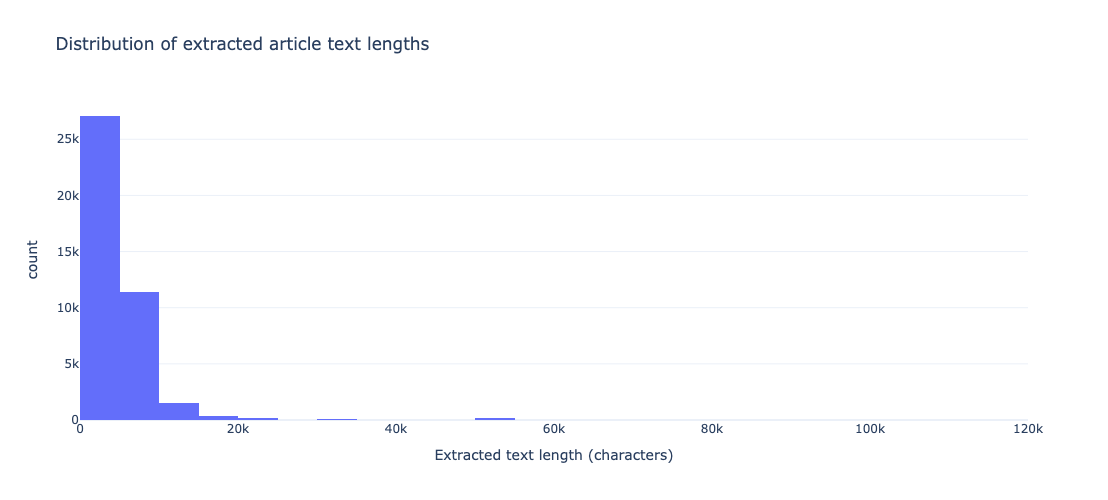

python3.10(56719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [84]:
fig_text_len = px.histogram(
    report_df,
    x="text_len",
    nbins=50,
    title="Distribution of extracted article text lengths",
    labels={"text_len": "Extracted text length (characters)", "count": "Number of articles"}
)

fig_text_len.update_layout(
    template="plotly_white",
    width=1000,
    height=500
)

fig_text_len.show()
fig_text_len.write_image("figures/text_length_distribution.pdf")

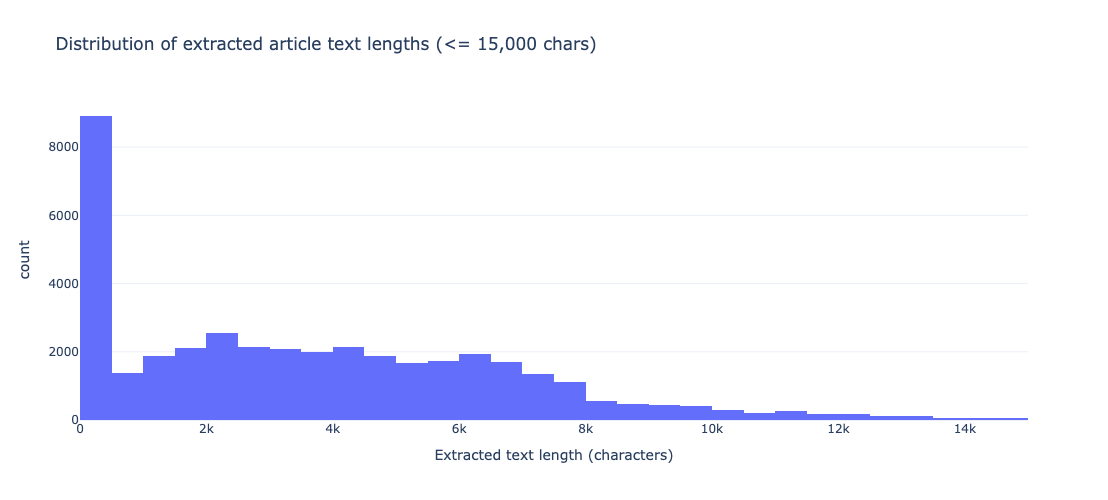

python3.10(56741) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [85]:
zoom_df = report_df[report_df["text_len"] <= 15000].copy()

fig_text_len_zoom = px.histogram(
    zoom_df,
    x="text_len",
    nbins=50,
    title="Distribution of extracted article text lengths (<= 15,000 chars)",
    labels={"text_len": "Extracted text length (characters)", "count": "Number of articles"}
)

fig_text_len_zoom.update_layout(
    template="plotly_white",
    width=1000,
    height=500
)

fig_text_len_zoom.show()
fig_text_len_zoom.write_image("figures/text_length_distribution_zoom.pdf")

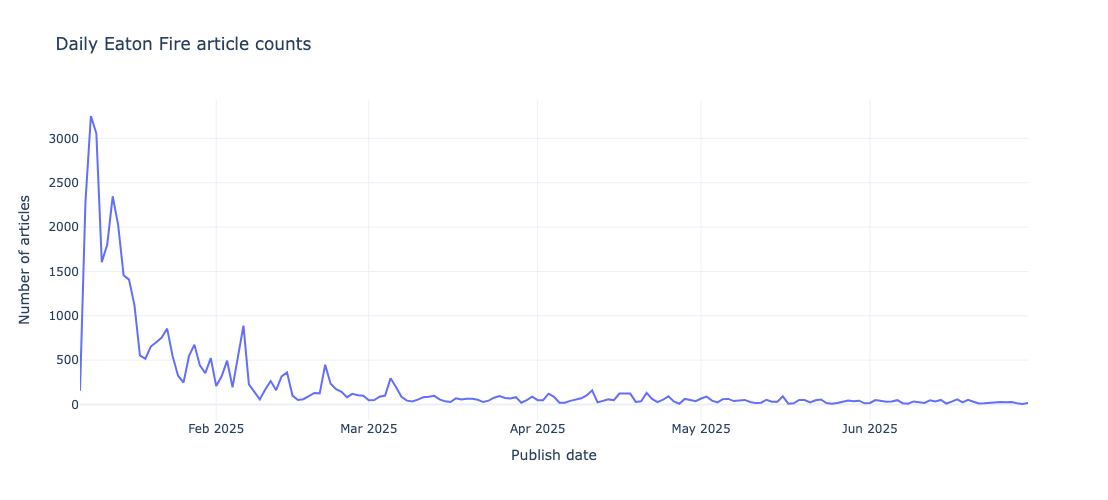

python3.10(56761) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [86]:
daily_counts = (
    report_df.dropna(subset=["publish_date"])
    .groupby(report_df["publish_date"].dt.date)
    .size()
    .reset_index(name="n_articles")
)

daily_counts["publish_date"] = pd.to_datetime(daily_counts["publish_date"])

fig_daily = px.line(
    daily_counts,
    x="publish_date",
    y="n_articles",
    title="Daily Eaton Fire article counts",
    labels={"publish_date": "Publish date", "n_articles": "Number of articles"}
)

fig_daily.update_layout(
    template="plotly_white",
    width=1100,
    height=500
)

fig_daily.show()
fig_daily.write_image("figures/daily_article_counts.pdf")

In [87]:
summary_stats = pd.DataFrame({
    "metric": [
        "Total records",
        "Records with text",
        "Records with usable text (>=1000 chars)",
        "Records without text",
        "Unique outlets",
        "Earliest publish date",
        "Latest publish date",
        "Median text length",
        "Mean text length"
    ],
    "value": [
        len(report_df),
        int(report_df["has_text"].sum()),
        int(report_df["usable_text"].sum()),
        int((~report_df["has_text"]).sum()),
        report_df["media_name"].nunique(),
        report_df["publish_date"].min(),
        report_df["publish_date"].max(),
        float(report_df["text_len"].median()),
        float(report_df["text_len"].mean())
    ]
})

summary_stats.to_csv("data/news_summary_stats.csv", index=False)
monthly_counts.to_csv("data/news_monthly_counts.csv", index=False)
top_outlets.to_csv("data/news_top_outlets.csv", index=False)
monthly_quality.to_csv("data/news_monthly_quality.csv", index=False)

In [ ]:
news_df = stories_df[stories_df["text_len"] >= MIN_TEXT_CHARS].copy()

# Normalize text for rough duplicate detection
news_df["text_norm"] = news_df["text"].apply(normalize_text_for_hashing)
news_df = news_df.drop_duplicates(subset=["text_norm"])

# dedupe by title + date, which can catch reposts
news_df["title_norm"] = (
    news_df["title"]
    .fillna("")
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

news_df = news_df.drop_duplicates(subset=["title_norm", "publish_date"])

print("Final corpus size:", len(news_df))
news_df[["publish_date", "media_name", "title", "text_len", "clean_url"]].head(10)

In [ ]:
keep_cols = [
    "mc_id", "publish_date", "indexed_date", "media_name", "media_url",
    "title", "url", "clean_url", "language", "text", "text_len"
]

final_df = news_df[keep_cols].copy()

final_df.to_csv("data/eaton_fire_news_jan_to_jun_2025.csv", index=False)
# final_df.to_parquet("data/eaton_fire_news_jan_to_jun_2025.parquet", index=False)

print("Saved:", len(final_df), "articles")

In [ ]:
print("Unique outlets:", final_df["media_name"].nunique())
print("Date range:", final_df["publish_date"].min(), "to", final_df["publish_date"].max())

outlet_counts = final_df["media_name"].value_counts().head(20)
print(outlet_counts)

monthly_counts = (
    final_df.assign(month=pd.to_datetime(final_df["publish_date"], errors="coerce").dt.to_period("M").astype(str))
            .groupby("month")
            .size()
            .reset_index(name="n_articles")
)

print(monthly_counts)